In [1]:
import pandas as pd

In [7]:
df = pd.read_csv(r"C:\Users\Quinn\Python_Decal\Quinn\homework8\state_data.csv")

In [8]:
print (df.shape)

(52, 4)


In [9]:
print (df.head())
print(df.tail())

  state   latitude   longitude        name
0    AK  63.588753 -154.493062      Alaska
1    AL  32.318231  -86.902298     Alabama
2    AR  35.201050  -91.831833    Arkansas
3    AZ  34.048928 -111.093731     Arizona
4    CA  36.778261 -119.417932  California
   state   latitude   longitude           name
47    VT  44.558803  -72.577841        Vermont
48    WA  47.751074 -120.740139     Washington
49    WI  43.784440  -88.787868      Wisconsin
50    WV  38.597626  -80.454903  West Virginia
51    WY  43.075968 -107.290284        Wyoming


In [10]:
print(df.columns)

Index(['state', 'latitude', 'longitude', 'name'], dtype='object')


In [11]:
# 1. different columns show the latitude longitude name and state for each state in the US
# 2. the first state is alaska 
# 3. the last state is wyoming
# 4. there are a total of 52 entries 
# 5. data appears to include places besides the 50 US states such as terratories and washington DC


In [12]:
median_lat = df["latitude"].median()
median_lon = df["longitude"].median()

print (median_lat)
print (median_lon)

39.4355155
-89.093198


In [14]:
df["lat_dist_from_median"]= abs(df["latitude"]-median_lat)
df["lon_dist_from_median"]= abs(df["longitude"]-median_lon)

In [15]:
print(df.shape)


(52, 6)


In [17]:
closest_lat_idx = df["lat_dist_from_median"].idxmin()
Farthest_lat_idx = df["lat_dist_from_median"].idxmax()

closest_lon_idx = df["lon_dist_from_median"].idxmin()
Farthest_lon_idx = df["lon_dist_from_median"].idxmax()

In [27]:
print(f"{df.loc[closest_lat_idx, "state"]} {df.loc[closest_lat_idx,"lat_dist_from_median"]:.2f}")
print(f"{df.loc[Farthest_lat_idx, "state"]} {df.loc[Farthest_lat_idx,"lat_dist_from_median"]:.2f}")

print(f"{df.loc[closest_lon_idx, "state"]} {df.loc[closest_lon_idx,"lon_dist_from_median"]:.2f}")
print(f"{df.loc[Farthest_lon_idx, "state"]} {df.loc[Farthest_lon_idx,"lon_dist_from_median"]:.2f}")

CO 0.11
AK 24.15
IL 0.31
HI 66.57


In [29]:
print(df.describe())
# this is a cool function it give summaries for each column. like count, mean, std dev, etc. This could be a very useful fucntion to get a handful of data from one small line of code. I found this in the data fram methods on the pandas documentation. 

        latitude   longitude  lat_dist_from_median  lon_dist_from_median
count  52.000000   52.000000             52.000000             52.000000
mean   39.153437  -92.824719              4.815714             14.535330
std     6.967697   19.431647              4.998411             13.280351
min    18.220833 -155.665857              0.114536              0.305330
25%    35.438381 -102.009600              1.564952              6.037732
50%    39.435516  -89.093198              3.890968             11.903743
75%    43.220246  -78.291302              6.133912             17.832342
max    63.588753  -66.590149             24.153237             66.572659


In [30]:
import matplotlib.pyplot as plt 
import seaborn as sns

In [33]:
df2 = sns.load_dataset("penguins")
print (df2.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


In [35]:
df2 = df2.dropna(axis=1)
print(df2.shape)
print(df2.columns)

(344, 2)
Index(['species', 'island'], dtype='object')


In [36]:
print (df2.shape)
print (df2.head())
print (df2.tail())


(344, 2)
  species     island
0  Adelie  Torgersen
1  Adelie  Torgersen
2  Adelie  Torgersen
3  Adelie  Torgersen
4  Adelie  Torgersen
    species  island
339  Gentoo  Biscoe
340  Gentoo  Biscoe
341  Gentoo  Biscoe
342  Gentoo  Biscoe
343  Gentoo  Biscoe


In [39]:
print ("shape:",df2.shape)
print ("rows:", df2.shape[0])
print ("columns:", df2.shape[1])

shape: (344, 2)
rows: 344
columns: 2


In [40]:
print (df2.head())
print(df2.tail())

  species     island
0  Adelie  Torgersen
1  Adelie  Torgersen
2  Adelie  Torgersen
3  Adelie  Torgersen
4  Adelie  Torgersen
    species  island
339  Gentoo  Biscoe
340  Gentoo  Biscoe
341  Gentoo  Biscoe
342  Gentoo  Biscoe
343  Gentoo  Biscoe


In [41]:
# the column names are species and island and they represent the penguin species and the island in which they reside

In [42]:
#for the scatter plot I am going to load in a new set of data as the penguins data got rid of all my numberical values after running the NaN command

In [44]:
df3 = sns.load_dataset("tips")
df3 = df3.dropna(axis=1)

print (df3.columns)
print (df3.shape)

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')
(244, 7)


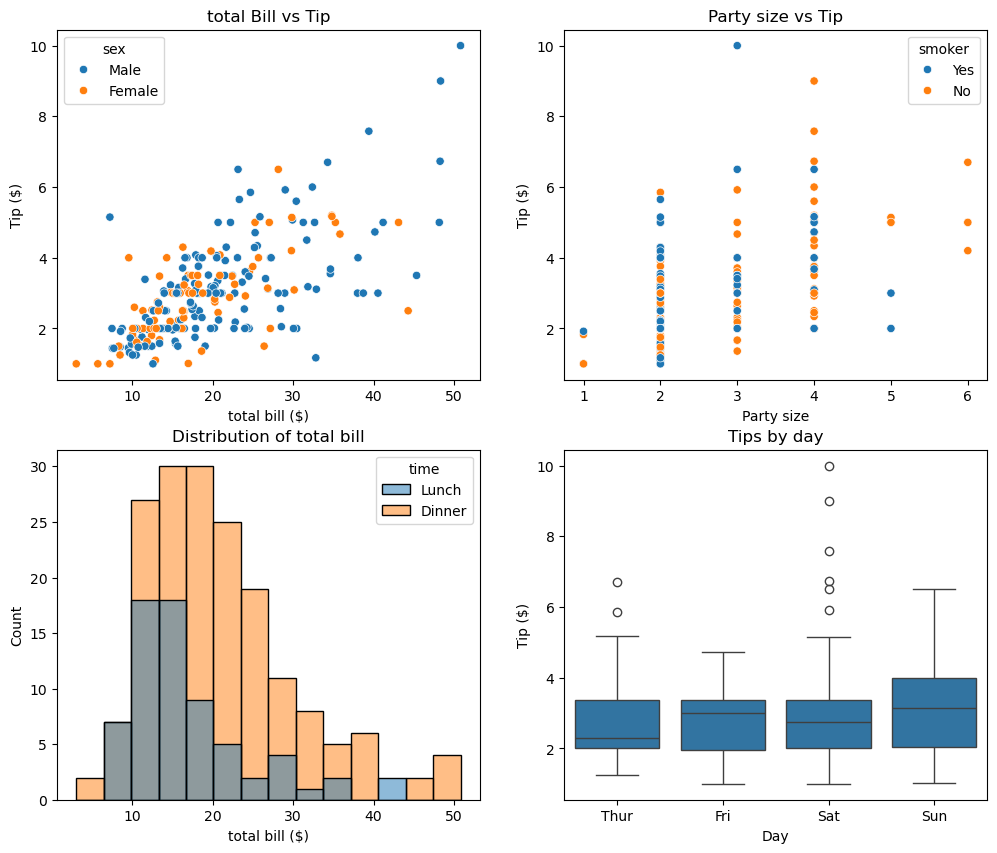

In [54]:
fig, axes = plt.subplots(2,2, figsize=(12,10))

sns.scatterplot(data=df3, x = "total_bill", y = "tip", hue = "sex", ax=axes[0,0])
axes[0,0].set_title("total Bill vs Tip")
axes[0,0].set_xlabel("total bill ($)")
axes[0,0].set_ylabel("Tip ($)")

sns.scatterplot(data=df3, x = "size", y = "tip", hue = "smoker", ax=axes[0,1])
axes[0,1].set_title("Party size vs Tip")
axes[0,1].set_xlabel("Party size")
axes[0,1].set_ylabel("Tip ($)")

sns.histplot(data=df3, x = "total_bill", hue = "time", ax=axes[1,0])
axes[1,0].set_title("Distribution of total bill")
axes[1,0].set_xlabel("total bill ($)")
axes[1,0].set_ylabel("Count")

sns.boxplot(data=df3, x = "day", y = "tip",  ax=axes[1,1])
axes[1,1].set_title("Tips by day")
axes[1,1].set_xlabel("Day")
axes[1,1].set_ylabel("Tip ($)")

plt.show()
    

In [ ]:
#This data shows the tips of a resturant and many different factors of the tips such as party size, tip amount, lunch and dinner tips, day of the week, etc. 
# each subplot shows something different, we have the total bill vs tip, the party size vs tip, the distribution of total billm and the tips by day
# it can be seen that larger tips come from larger bills but not necessarily larger parties, majority of the high paying bills were from dinner and more tips were recieved on the weekends than on the weekdays.
